# Vanilla vs noMHC ProteinMPNN — MEL5 TCR / MART-1 (3HG1), companion to notebooks 17 & 19

Same ablation as notebooks 17 (T=0.1/50K, native 6AM5/6AMU) and 19 (T=0.3/10K, same crystals), but on
a **new structure**: **3HG1** — the MEL5 TCR (a published, well-characterized MART-1-specific human
TCR) bound to HLA-A2 presenting `ELAGIGILTV` (MART-1 26-35, A27L variant). Same 5-chain complex
convention (A=MHC, B=β2m, C=peptide designed, D=TCRα, E=TCRβ fixed).

**Why this structure:** cross-referencing `/home/ubuntu/adimab/tcrs.csv` (proprietary Adimab TCR
panel) against every structure in `inputs/pmhc_tcr_dataset/` found exactly one overlap — Adimab clone
`CAB60174_G01`'s CDR3α (`AVNVAGKST`) **and** CDR3β (`AWSETGLGTGELF`) both match 3HG1's TCR chains
verbatim (see `outputs/analysis/adimab_tcr_overlap.csv`) — i.e. this is (or is essentially identical
to) the MEL5 TCR, giving a concrete reason to run the same weights ablation on this backbone.

- **vanilla** — `model_name=v_48_020` (`outputs/mpnn_3hg1_100k/seqs/vanilla_3HG1.fa`, complete, 44,127 designs).
- **noMHC** — `model_name=proteinmpnn_nomhc` (`outputs/mpnn_3hg1_100k/seqs/nomhc_3HG1.fa`, may be in
  progress — see data-status cell), T=0.1, target 40,000 (reduced from an initial 100K).

Sections:
1. Load + data-status inventory
2. Basic stats & duplication
3. Recovery — overall identity & per-position, vanilla vs noMHC
4. Amino-acid composition & distribution shift (Δ vanilla − noMHC)
5. Sequence logo, side by side
6. Memorization probe — exact/near-exact recovery, gap by position
7. Summary & verdict

In [24]:
from pathlib import Path
import re, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except Exception:
    display = print
warnings.filterwarnings("ignore")
sns.set_context("notebook"); sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("/home/ubuntu/if-mhc")
FIGDIR = ROOT / "outputs/analysis/figures_nomhc_vs_vanilla_3hg1"; FIGDIR.mkdir(parents=True, exist_ok=True)

AA = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDX = {a: i for i, a in enumerate(AA)}
L = 10
NAT = {"3HG1": "ELAGIGILTV"}   # MART-1 26-35 A27L, presented by HLA-A2
ANCHORS = [2, 10]              # 1-based P2 / PΩ(P10), HLA-A*02 anchors (same convention as 17/19)
CRYSTALS = ["3HG1"]
TEMP = 0.1; NSEQ_TARGET = 40000

CAMPAIGN_DIR = ROOT / "outputs/mpnn_3hg1_100k"
MODEL_COLOR = {"vanilla": "#1f77b4", "noMHC": "#d62728"}

## 1. Load sequences

In [46]:
def load_fasta(path, L=L):
    '''Parse a ProteinMPNN FASTA. First record (no "sample=") is native/reference; rest are designs.'''
    p = Path(path)
    if not p.exists():
        return pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample","model_name"])
    lines = p.read_text().splitlines()
    rows = []
    for i in range(0, len(lines)-1, 2):
        h, s = lines[i], lines[i+1].strip()
        if not h.startswith(">") or "sample=" not in h or len(s) != L:
            continue
        d = dict(re.findall(r'(\w+)=([-\d.]+)', h))
        rows.append({"peptide": s, "score": float(d.get("score","nan")),
                     "global_score": float(d.get("global_score","nan")),
                     "seq_recovery": float(d.get("seq_recovery","nan")),
                     "T": float(d.get("T","nan")), "sample": int(float(d.get("sample",0)))})
    return pd.DataFrame(rows)

def n_records(path):
    p = Path(path)
    if not p.exists(): return 0
    return sum(1 for l in open(p) if l.startswith(">") and "sample=" in l)

def resolve_fasta(weights, pid):
    '''run_3hg1_100k.sh renames seqs/<pid>.fa -> seqs/<weights>_<pid>.fa on completion. Mid-run,
    the bare <pid>.fa is what's actively being written -- fall back to it if the tagged file isn't
    there yet. vanilla and noMHC were run concurrently in separate directories to avoid both writing
    to the same bare seqs/<pid>.fa path at once (outputs/mpnn_3hg1_100k/seqs/ for vanilla,
    outputs/mpnn_3hg1_100k/_nomhc_parallel/seqs/ for noMHC) -- check the RIGHT bare location per
    weight set, not just one shared path, or both "vanilla" and "nomhc" silently resolve to the same
    (vanilla) file.'''
    tagged = CAMPAIGN_DIR / f"seqs/{weights}_{pid}.fa"
    # NOTE: while the parallel run is active, seqs/<pid>.fa (bare, no subdir) is ALWAYS vanilla's file
    # -- never fall back to it for noMHC, or the two would silently alias to the same data.
    bare_paths = [CAMPAIGN_DIR / f"seqs/{pid}.fa"] if weights == "vanilla" else \
                 [CAMPAIGN_DIR / f"_nomhc_parallel/seqs/{pid}.fa"]
    if tagged.exists():
        return tagged, n_records(tagged), "complete" if n_records(tagged) >= NSEQ_TARGET else f"in progress ({n_records(tagged):,})"
    for bare in bare_paths:
        if bare.exists():
            return bare, n_records(bare), f"in progress, not yet renamed ({n_records(bare):,}) [{bare.parent}]"
    return tagged, 0, "not started"

frames = []
status = {}
for pid in CRYSTALS:
    for weights in ["vanilla", "nomhc"]:
        path, n, note = resolve_fasta(weights, pid)
        d = load_fasta(path); d["model"] = "vanilla" if weights == "vanilla" else "noMHC"; d["crystal"] = pid
        frames.append(d)
        status[(d["model"].iloc[0] if len(d) else ("vanilla" if weights=="vanilla" else "noMHC"), pid)] = (path, len(d), note)

df = pd.concat(frames, ignore_index=True)
df["native"] = df.crystal.map(NAT)
pos_cols = [f"p{i+1}" for i in range(L)]
df[pos_cols] = df.peptide.apply(lambda s: pd.Series(list(s)))
print(f"loaded {len(df):,} rows across {df.model.nunique()} models x {df.crystal.nunique()} structure(s)")

loaded 53,240 rows across 2 models x 1 structure(s)


### Data-status inventory — what this run actually has loaded

In [47]:
inv = pd.DataFrame([
    {"model": m, "crystal": p, "source": str(path.relative_to(ROOT)), "n_designs": n, "status": note}
    for (m, p), (path, n, note) in status.items()
]).sort_values(["crystal","model"])
display(inv)
if inv.n_designs.min() < NSEQ_TARGET:
    print(f"NOTE: at least one target is not yet at the {NSEQ_TARGET:,} target -- all comparisons below use")
    print("whatever is currently on disk. Re-run this notebook later for final numbers.")

,model,crystal,source,n_designs,status
1,noMHC,3HG1,outputs/mpnn_3hg1_100k/_nomhc_parallel/seqs/3H...,26341,"in progress, not yet renamed (26,341) [/home/u..."
0,vanilla,3HG1,outputs/mpnn_3hg1_100k/seqs/3HG1.fa,26899,"in progress, not yet renamed (26,899) [/home/u..."


NOTE: at least one target is not yet at the 40,000 target -- all comparisons below use
whatever is currently on disk. Re-run this notebook later for final numbers.


## 2. Basic stats & duplication, per model

In [48]:
df

,peptide,score,global_score,seq_recovery,T,sample,model,crystal,native,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10
0,MVPGTGITVL,0.8408,1.7655,0.3,0.1,1,vanilla,3HG1,ELAGIGILTV,M,V,P,G,T,G,I,T,V,L
1,MLPGTGITVL,0.8541,1.7510,0.4,0.1,2,vanilla,3HG1,ELAGIGILTV,M,L,P,G,T,G,I,T,V,L
2,MLPGTGIVVL,0.8908,1.7575,0.4,0.1,3,vanilla,3HG1,ELAGIGILTV,M,L,P,G,T,G,I,V,V,L
3,MLPGTGEVVL,0.9195,1.7541,0.3,0.1,4,vanilla,3HG1,ELAGIGILTV,M,L,P,G,T,G,E,V,V,L
4,MLPGTGITVL,0.8349,1.7666,0.4,0.1,5,vanilla,3HG1,ELAGIGILTV,M,L,P,G,T,G,I,T,V,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53235,MLPGIGIRVL,0.5840,1.7605,0.5,0.1,26337,noMHC,3HG1,ELAGIGILTV,M,L,P,G,I,G,I,R,V,L
53236,MLPGIGIRVL,0.5845,1.7703,0.5,0.1,26338,noMHC,3HG1,ELAGIGILTV,M,L,P,G,I,G,I,R,V,L
53237,MLPGIGIRVL,0.6244,1.7707,0.5,0.1,26339,noMHC,3HG1,ELAGIGILTV,M,L,P,G,I,G,I,R,V,L
53238,MLPGIGIRVL,0.5813,1.7697,0.5,0.1,26340,noMHC,3HG1,ELAGIGILTV,M,L,P,G,I,G,I,R,V,L


,crystal,model,n,n_unique,pct_unique,native_exact_hits,mean_score,median_score
0,3HG1,noMHC,26341.0,27.0,0.1,0.0,0.6072,0.6029
1,3HG1,vanilla,26899.0,87.0,0.3,0.0,0.8713,0.8684


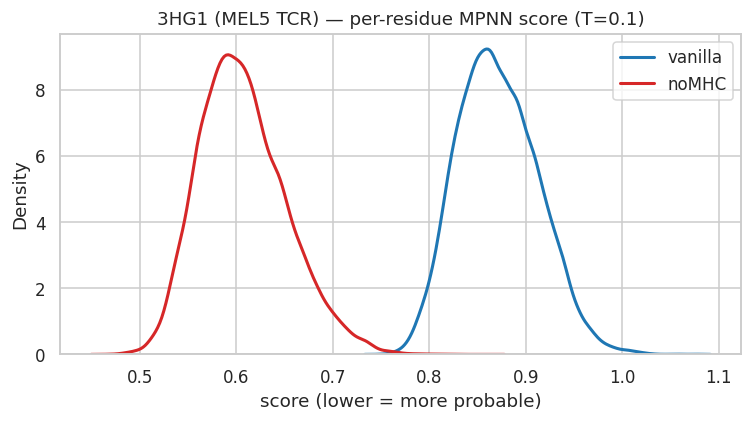

In [49]:
def basic_stats(sub):
    n = len(sub); u = sub.peptide.nunique()
    exact = int((sub.peptide == sub.native.iloc[0]).sum()) if n else 0
    return pd.Series({"n": n, "n_unique": u, "pct_unique": round(100*u/n, 1) if n else np.nan,
                       "native_exact_hits": exact,
                       "mean_score": round(sub.score.mean(), 4) if n else np.nan,
                       "median_score": round(sub.score.median(), 4) if n else np.nan})

stats = df.groupby(["crystal","model"]).apply(basic_stats).reset_index()
display(stats)

fig, ax = plt.subplots(figsize=(7, 4))
for m in ["vanilla","noMHC"]:
    s = df[df.model==m].score.dropna()
    if len(s): sns.kdeplot(s, ax=ax, color=MODEL_COLOR[m], label=m, lw=2)
ax.set_title(f"3HG1 (MEL5 TCR) — per-residue MPNN score (T={TEMP})"); ax.set_xlabel("score (lower = more probable)")
ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR/"score_distributions.png", bbox_inches="tight"); plt.show()

## 3. Recovery vs native — overall identity & per-position, vanilla vs noMHC

,crystal,model,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,3HG1,vanilla,0.0,77.2,0.0,100.0,26.7,100.0,87.9,0.0,1.5,0.0
1,3HG1,noMHC,0.0,95.4,0.0,100.0,100.0,100.0,99.9,0.0,0.7,0.0


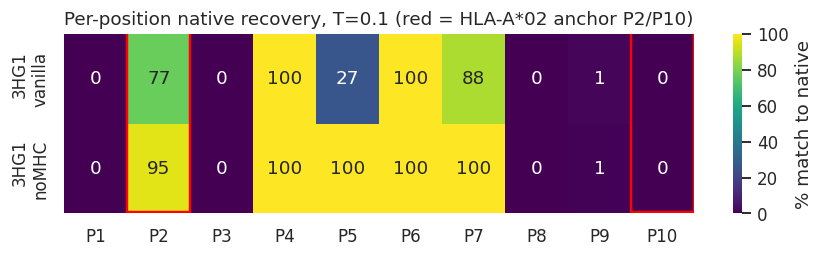

In [50]:
def perpos_recovery(seqs, nat):
    if len(seqs) == 0: return np.full(L, np.nan)
    P = np.array([list(s) for s in seqs])
    return (P == np.array(list(nat))).mean(0) * 100

rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        rec = perpos_recovery(seqs, nat)
        rows.append({"crystal": pid, "model": m, **{f"P{i+1}": rec[i] for i in range(L)}})
perpos_df = pd.DataFrame(rows)
display(perpos_df.round(1))

M = perpos_df[[f"P{i+1}" for i in range(L)]].values
labels = [f"{r.crystal}\n{r.model}" for r in perpos_df.itertuples()]
fig, ax = plt.subplots(figsize=(8, 0.55*len(M)+1.4))
sns.heatmap(M, annot=True, fmt=".0f", cmap="viridis", vmin=0, vmax=max(40, np.nanmax(M)),
            xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=labels,
            cbar_kws={"label":"% match to native"}, ax=ax)
for a in ANCHORS:
    ax.add_patch(plt.Rectangle((a-1, -0.02), 1, len(M), fill=False, ec="red", lw=1.6))
ax.set_title(f"Per-position native recovery, T={TEMP} (red = HLA-A*02 anchor P2/P10)")
plt.tight_layout(); plt.savefig(FIGDIR/"perposition_recovery.png", bbox_inches="tight"); plt.show()

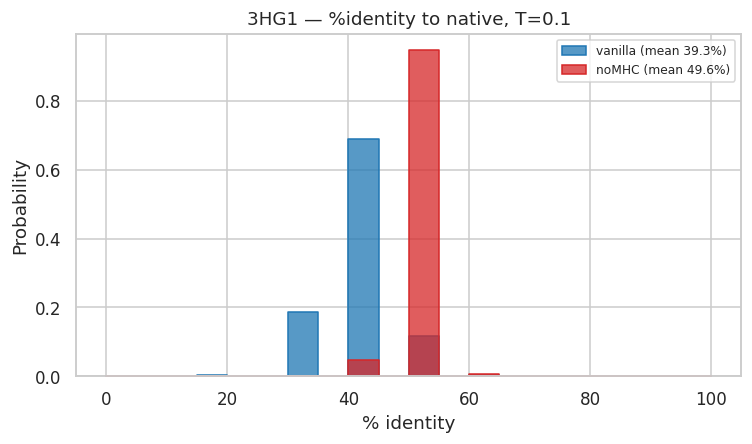

mean  median   std
crystal model                       
3HG1    noMHC    49.60    50.0  2.28
        vanilla  39.32    40.0  5.73

In [51]:
P_all = {(pid,m): np.array([list(s) for s in df[(df.crystal==pid)&(df.model==m)].peptide.values])
         for pid in CRYSTALS for m in ["vanilla","noMHC"]}
for pid in CRYSTALS:
    nat = np.array(list(NAT[pid]))
    for m in ["vanilla","noMHC"]:
        P = P_all[(pid,m)]
        if len(P)==0: continue
        ham = (P != nat).sum(1)
        df.loc[(df.crystal==pid)&(df.model==m), "hamming"] = ham
        df.loc[(df.crystal==pid)&(df.model==m), "identity"] = 100*(1 - ham/L)

fig, ax = plt.subplots(figsize=(7, 4.2))
for m in ["vanilla","noMHC"]:
    s = df[df.model==m].identity.dropna()
    if len(s): sns.histplot(s, bins=np.arange(0,101,5), ax=ax, color=MODEL_COLOR[m],
                             label=f"{m} (mean {s.mean():.1f}%)", element="step", stat="probability")
ax.set_title(f"3HG1 — %identity to native, T={TEMP}"); ax.set_xlabel("% identity"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"identity_distributions.png", bbox_inches="tight"); plt.show()
df.groupby(["crystal","model"]).identity.agg(["mean","median","std"]).round(2)

In [52]:
for apos in ANCHORS:
    col = f"p{apos}"
    for pid in CRYSTALS:
        nat_res = NAT[pid][apos-1]
        for m in ["vanilla","noMHC"]:
            sub = df[(df.crystal==pid)&(df.model==m)]
            if len(sub)==0: continue
            frac = (sub[col]==nat_res).mean()*100
            print(f"P{apos} anchor, {pid} ({m}): native={nat_res} recovered in {frac:.1f}% of designs")
print("(full anchor composition table shown in section 4's per-position heatmap)")

P2 anchor, 3HG1 (vanilla): native=L recovered in 77.2% of designs
P2 anchor, 3HG1 (noMHC): native=L recovered in 95.4% of designs
P10 anchor, 3HG1 (vanilla): native=V recovered in 0.0% of designs
P10 anchor, 3HG1 (noMHC): native=V recovered in 0.0% of designs
(full anchor composition table shown in section 4's per-position heatmap)


## 4. Amino-acid composition & distribution shift (Δ = vanilla − noMHC)

Same backbone, same T=0.1 — any AA-frequency difference here is attributable **only** to the model
weights.

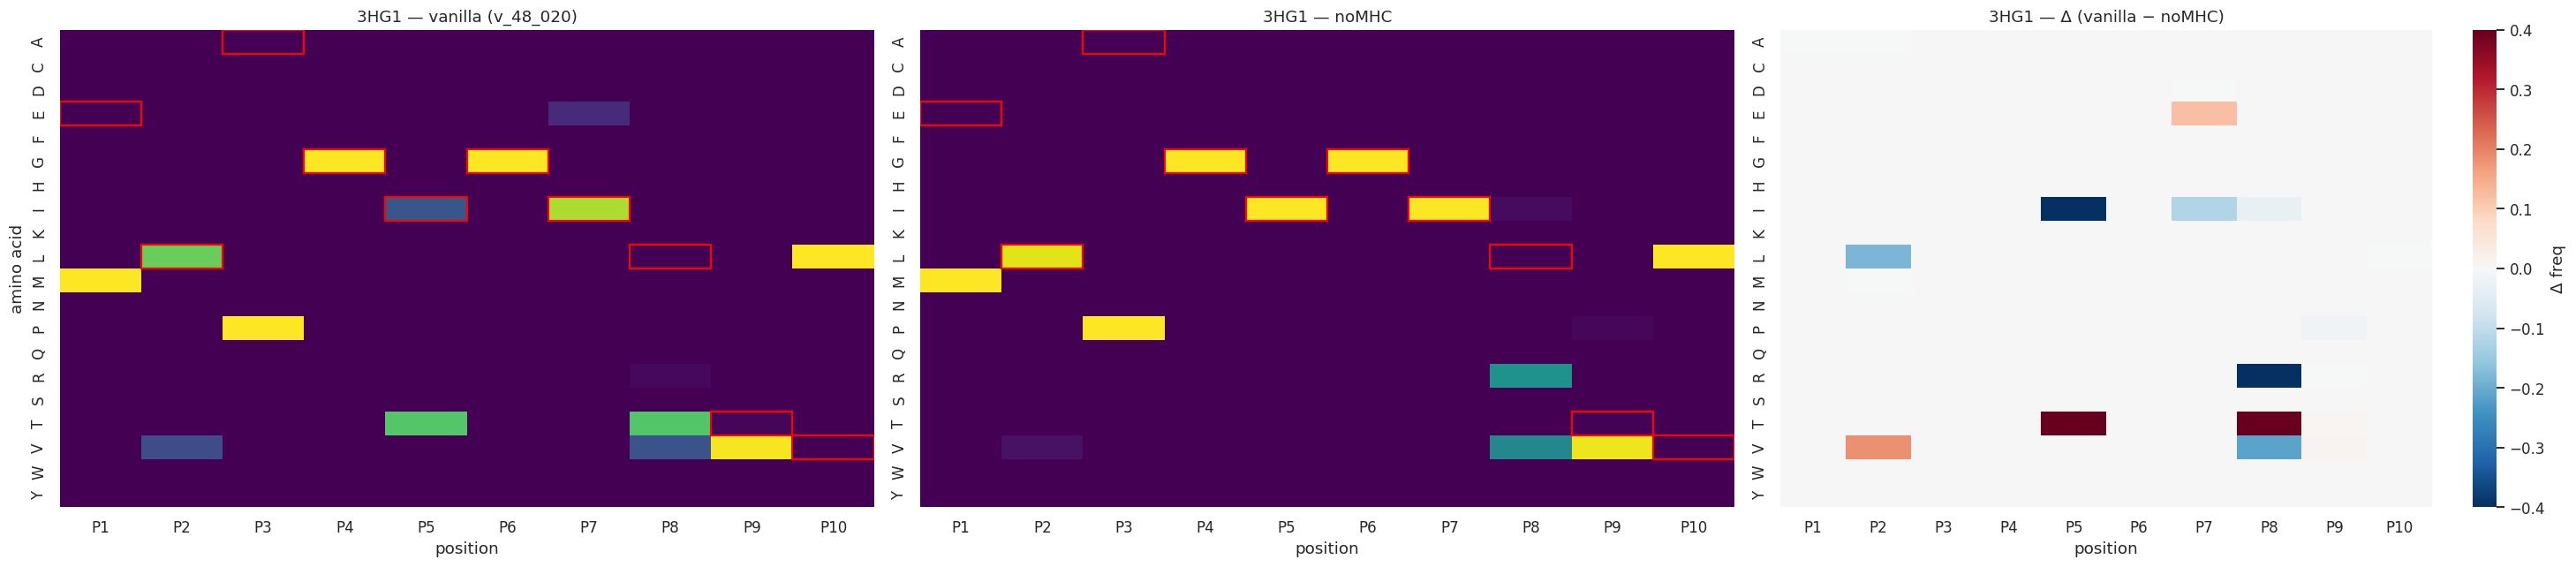

In [53]:
def freq_matrix(seqs, L=L):
    M = np.zeros((L, len(AA)))
    for s in seqs:
        for i, c in enumerate(s):
            if c in AA_IDX: M[i, AA_IDX[c]] += 1
    M /= np.clip(M.sum(1, keepdims=True), 1, None)
    return pd.DataFrame(M, columns=AA, index=list(range(L)))

for pid in CRYSTALS:
    nat = NAT[pid]
    fV = freq_matrix(df[(df.crystal==pid)&(df.model=="vanilla")].peptide.values)
    fN = freq_matrix(df[(df.crystal==pid)&(df.model=="noMHC")].peptide.values)
    fig, ax = plt.subplots(1, 3, figsize=(2.1*L+6, 6))
    for a, (M, t) in zip(ax[:2], [(fV,"vanilla (v_48_020)"), (fN,"noMHC")]):
        sns.heatmap(M.T, cmap="viridis", vmin=0, vmax=1, ax=a, cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA)
        for i,c in enumerate(nat):
            if c in AA_IDX: a.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.4))
        a.set_title(f"{pid} — {t}"); a.set_xlabel("position")
    sns.heatmap((fV-fN).T, cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4, ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA, cbar_kws={"label":"Δ freq"})
    ax[2].set_title(f"{pid} — Δ (vanilla − noMHC)"); ax[2].set_xlabel("position")
    ax[0].set_ylabel("amino acid")
    plt.tight_layout(); plt.savefig(FIGDIR/f"aa_freq_delta_{pid}.png", bbox_inches="tight"); plt.show()

## 5. Sequence logo, side by side

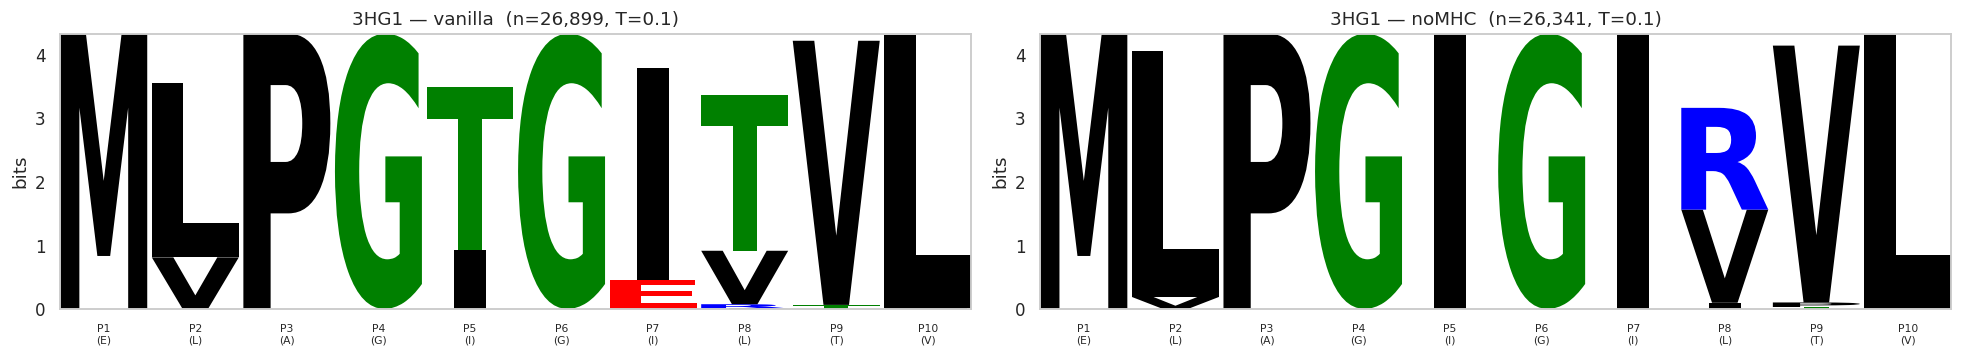

In [54]:
import logomaker
fig, axes = plt.subplots(1, 2, figsize=(max(6,L*0.9)*2, 3.4))
for c, m in enumerate(["vanilla","noMHC"]):
    pid = CRYSTALS[0]; nat = NAT[pid]
    seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
    ax = axes[c]
    if len(seqs) == 0:
        ax.set_axis_off(); ax.set_title(f"{pid} {m} (no data yet)"); continue
    fmat = freq_matrix(seqs)
    info = logomaker.transform_matrix(fmat.copy(), from_type="probability", to_type="information")
    logomaker.Logo(info, ax=ax, color_scheme="chemistry"); ax.grid(False)
    ax.set_ylim(0, 4.32)
    ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n({nat[i]})" for i in range(L)], fontsize=7)
    ax.set_title(f"{pid} — {m}  (n={len(seqs):,}, T={TEMP})"); ax.set_ylabel("bits")
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logo_side_by_side.png", bbox_inches="tight"); plt.show()

## 6. Memorization probe

3HG1/MEL5 is a well-published, widely-studied TCR-pMHC structure (deposited well before any
plausible ProteinMPNN training cutoff), so vanilla weights are a *plausible* trainset member for this
exact complex; `proteinmpnn_nomhc` is guaranteed to have never seen this or any other MHC/TCR
structure. A vanilla-noMHC gap concentrated on this backbone specifically is the memorization
fingerprint, same logic as notebooks 17/19.

In [55]:
rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        sub = df[(df.crystal==pid)&(df.model==m)]
        if len(sub)==0: continue
        rows.append({"crystal":pid, "model":m, "n":len(sub),
                      "exact_hits": int((sub.hamming==0).sum()),
                      "hamming_le1": int((sub.hamming<=1).sum()),
                      "hamming_le2": int((sub.hamming<=2).sum()),
                      "pct_exact": round(100*(sub.hamming==0).mean(),4),
                      "mean_identity_pct": round(sub.identity.mean(),2)})
exact_df = pd.DataFrame(rows)
display(exact_df)
print("Exact full-sequence native recovery is the strongest single memorization signal: any model")
print("regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the")
print("~1/20^(non-anchor positions) chance rate.")

,crystal,model,n,exact_hits,hamming_le1,hamming_le2,pct_exact,mean_identity_pct
0,3HG1,vanilla,26899,0,0,0,0.0,39.32
1,3HG1,noMHC,26341,0,0,0,0.0,49.60


Exact full-sequence native recovery is the strongest single memorization signal: any model
regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the
~1/20^(non-anchor positions) chance rate.


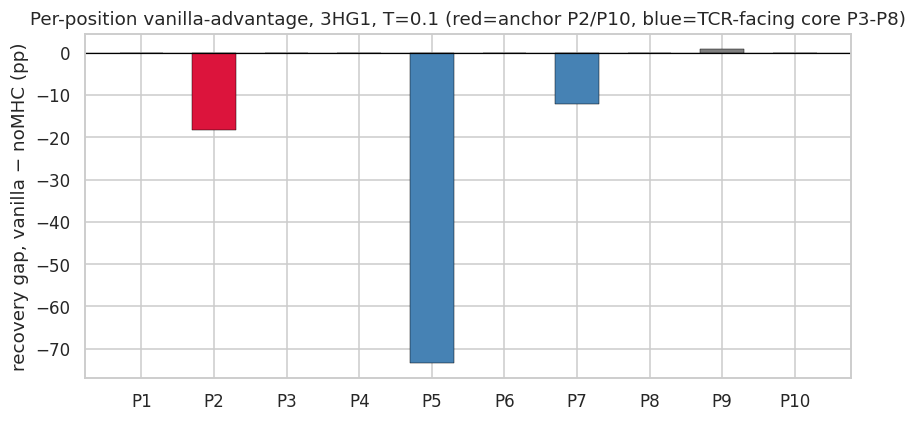

per-position breakdown:
  3HG1 P2: vanilla-noMHC gap = -18.2pp
  3HG1 P10: vanilla-noMHC gap = +0.0pp

mean vanilla-advantage at anchors (P2,P10): -9.10pp
mean vanilla-advantage at TCR-facing core (P3-P8): -14.22pp


In [56]:
gap_rows = []
for pid in CRYSTALS:
    pv = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="vanilla")][[f"P{i+1}" for i in range(L)]].values[0]
    pn = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="noMHC")][[f"P{i+1}" for i in range(L)]].values[0]
    gap_rows.append(pv - pn)
gap = np.array(gap_rows)

fig, ax = plt.subplots(figsize=(8,4))
core = list(range(2,8))  # 0-based P3..P8
for i,pid in enumerate(CRYSTALS):
    colors = ["crimson" if (j+1) in ANCHORS else ("steelblue" if j in core else "grey") for j in range(L)]
    ax.bar(np.arange(L), gap[i], width=0.6, color=colors, edgecolor="k", linewidth=.3)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}" for i in range(L)])
ax.set_ylabel("recovery gap, vanilla − noMHC (pp)")
ax.set_title(f"Per-position vanilla-advantage, 3HG1, T={TEMP} (red=anchor P2/P10, blue=TCR-facing core P3-P8)")
plt.tight_layout(); plt.savefig(FIGDIR/"gap_by_position.png", bbox_inches="tight"); plt.show()

anchor_idx = [a-1 for a in ANCHORS]
anchor_gap = gap[:, anchor_idx].mean()
core_gap = gap[:, core].mean()
print("per-position breakdown:")
for pid in CRYSTALS:
    for a in ANCHORS:
        print(f"  {pid} P{a}: vanilla-noMHC gap = {gap[0, a-1]:+.1f}pp")
print(f"\nmean vanilla-advantage at anchors (P2,P10): {anchor_gap:+.2f}pp")
print(f"mean vanilla-advantage at TCR-facing core (P3-P8): {core_gap:+.2f}pp")

## 7. Summary & verdict

In [57]:
summary = {
    "structure": "3HG1 (MEL5 TCR / MART-1 / HLA-A2)",
    "temperature": TEMP,
    "vanilla_status": status[("vanilla","3HG1")][2],
    "noMHC_status": status[("noMHC","3HG1")][2],
    "vanilla_mean_identity_pct": float(exact_df[exact_df.model=='vanilla'].mean_identity_pct.values[0]) if len(exact_df[exact_df.model=='vanilla']) else None,
    "noMHC_mean_identity_pct": float(exact_df[exact_df.model=='noMHC'].mean_identity_pct.values[0]) if len(exact_df[exact_df.model=='noMHC']) else None,
    "anchor_gap_pp": round(float(anchor_gap), 2),
    "core_gap_pp": round(float(core_gap), 2),
}
import json; print(json.dumps(summary, indent=2))

exact_df.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_3hg1_recovery.csv", index=False)
perpos_df.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_3hg1_perposition.csv", index=False)
pd.Series(summary).to_json(ROOT/"outputs/analysis/nomhc_vs_vanilla_3hg1_summary.json")
print("\nsaved outputs/analysis/nomhc_vs_vanilla_3hg1_{recovery,perposition}.csv + summary.json")

if len(exact_df[exact_df.model=="noMHC"]):
    vn = exact_df[exact_df.model=='vanilla'].mean_identity_pct.values[0]
    nn = exact_df[exact_df.model=='noMHC'].mean_identity_pct.values[0]
    print(f"\nVERDICT: vanilla mean identity {vn:.1f}% vs noMHC {nn:.1f}% (gap {vn-nn:+.1f}pp) on 3HG1/MEL5.")
    print(f"anchor gap {anchor_gap:+.1f}pp, core gap {core_gap:+.1f}pp -- read the per-position breakdown")
    print("above before concluding memorization either way (single dominant position vs diffuse effect).")
else:
    print("\nnoMHC not yet available -- re-run once outputs/mpnn_3hg1_100k/seqs/nomhc_3HG1.fa completes.")

{
  "structure": "3HG1 (MEL5 TCR / MART-1 / HLA-A2)",
  "temperature": 0.1,
  "vanilla_status": "in progress, not yet renamed (26,899) [/home/ubuntu/if-mhc/outputs/mpnn_3hg1_100k/seqs]",
  "noMHC_status": "in progress, not yet renamed (26,341) [/home/ubuntu/if-mhc/outputs/mpnn_3hg1_100k/_nomhc_parallel/seqs]",
  "vanilla_mean_identity_pct": 39.32,
  "noMHC_mean_identity_pct": 49.6,
  "anchor_gap_pp": -9.1,
  "core_gap_pp": -14.22
}

saved outputs/analysis/nomhc_vs_vanilla_3hg1_{recovery,perposition}.csv + summary.json

VERDICT: vanilla mean identity 39.3% vs noMHC 49.6% (gap -10.3pp) on 3HG1/MEL5.
anchor gap -9.1pp, core gap -14.2pp -- read the per-position breakdown
above before concluding memorization either way (single dominant position vs diffuse effect).


In [58]:
df.to_csv('../if_generated_3HG1.csv')

In [59]:
df = df.drop_duplicates(['peptide','model'])

In [60]:
df.value_counts('model')

model
vanilla    87
noMHC      27
Name: count, dtype: int64

In [61]:
df

,peptide,score,global_score,seq_recovery,T,sample,model,crystal,native,p1,...,p3,p4,p5,p6,p7,p8,p9,p10,hamming,identity
0,MVPGTGITVL,0.8408,1.7655,0.3,0.1,1,vanilla,3HG1,ELAGIGILTV,M,...,P,G,T,G,I,T,V,L,7.0,30.0
1,MLPGTGITVL,0.8541,1.7510,0.4,0.1,2,vanilla,3HG1,ELAGIGILTV,M,...,P,G,T,G,I,T,V,L,6.0,40.0
2,MLPGTGIVVL,0.8908,1.7575,0.4,0.1,3,vanilla,3HG1,ELAGIGILTV,M,...,P,G,T,G,I,V,V,L,6.0,40.0
3,MLPGTGEVVL,0.9195,1.7541,0.3,0.1,4,vanilla,3HG1,ELAGIGILTV,M,...,P,G,T,G,E,V,V,L,7.0,30.0
5,MVPGIGIVVL,0.9573,1.7505,0.4,0.1,6,vanilla,3HG1,ELAGIGILTV,M,...,P,G,I,G,I,V,V,L,6.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42206,MMPGIGIRVL,0.7331,1.7718,0.4,0.1,15308,noMHC,3HG1,ELAGIGILTV,M,...,P,G,I,G,I,R,V,L,6.0,40.0
44516,MVPGIGEVVL,0.7698,1.7827,0.3,0.1,17618,noMHC,3HG1,ELAGIGILTV,M,...,P,G,I,G,E,V,V,L,7.0,30.0
48457,ALPGIGIVVL,0.7096,1.7654,0.5,0.1,21559,noMHC,3HG1,ELAGIGILTV,A,...,P,G,I,G,I,V,V,L,5.0,50.0
49585,MLPGTGIVVL,0.5928,1.7568,0.4,0.1,22687,noMHC,3HG1,ELAGIGILTV,M,...,P,G,T,G,I,V,V,L,6.0,40.0
